# mechanism_viewer examples

## Use Little's MCAR test for detection of missing data mechanism
This notebook contains examples of how to use functions from `mcar_little_test.py` to evaluate whether missingness is likely MCAR.

The module `mcar_little_test.py` has 2 types of Little's MCAR test: the global version, `little_mcar_test()`, and the pairwise version, `little_mcar_pairwise()`. The global version performs a chi-square test on the entire dataset, while the last one performs a separate t-test for every pair of columns possible. As a consequence `little_mcar_test()` returns one global p-value, while `little_mcar_pairwise()` returns a matrix dataframe with every p-value of each pair combination, since each t-test returns a p-value.

>Note: After some testing, it has been concluded that this Little's MCAR test cannot identify columns with MNAR data missing mechanism. The test does not directly distinguish MAR from MNAR. However, datasets that have no MAR columns but have columns with MNAR pattern, are most of the time detected as MCAR. Meanwhile, the presence of a MAR column will likely make the test detect non-MCAR. Additional diagnostics should be conducted to verify the missing data patterns.

### 1. Generate synthetic datasets with missing values

To better understand the different outputs the functions can return, 2 different synthetic datasets will be generated.

The first dataset has one fully observed column and three columns with only MCAR missingness pattern, but different missing rates.

Meanwhile, the second dataset has one fully observed column and three columns with MCAR missingness (with different missing rates), but the last column has a MAR missingness pattern.

In [1]:
from mechanism_viewer import generate_dataset_with_missing_data, ColType

data = generate_dataset_with_missing_data( 100, [ColType.DISCRETE, ColType.CONTINUOUS, ColType.CONTINUOUS,
                                                 ColType.CONTINUOUS], 1, ["MCAR", "MCAR", "MCAR"], [0.2, 0.4, 0.6])

display(data.head(10))

,Col1,Col2,Col3,Col4
0,5,-0.062679,0.086590,NaN
1,4,NaN,NaN,NaN
2,4,-0.985726,1.167782,-0.268889
3,5,NaN,0.254421,NaN
4,5,NaN,0.337603,2.573360
5,3,-0.792873,NaN,NaN
6,5,-0.107030,NaN,NaN
7,4,-1.035242,NaN,NaN
8,6,NaN,0.394452,0.198085
9,7,-1.197878,-0.420984,NaN


In [2]:
from mechanism_viewer import generate_dataset_with_missing_data, ColType

data2 = generate_dataset_with_missing_data( 100, [ColType.DISCRETE, ColType.CONTINUOUS, ColType.CONTINUOUS,
                                                 ColType.CONTINUOUS, ColType.CONTINUOUS], 1, ["MCAR", "MCAR",
                                                 "MCAR", "MAR"], [0.2, 0.4, 0.6, 0.6])

display(data2.head(10))

,Col1,Col2,Col3,Col4,Col5
0,5,-0.062679,NaN,NaN,NaN
1,4,NaN,NaN,1.126565,NaN
2,4,-0.985726,NaN,-0.268889,NaN
3,5,NaN,0.254421,NaN,NaN
4,5,-0.530258,NaN,NaN,NaN
5,3,-0.792873,-0.411877,NaN,2.632382
6,5,NaN,-0.487606,NaN,NaN
7,4,-1.035242,NaN,-0.024125,NaN
8,6,-0.553649,NaN,0.198085,NaN
9,7,NaN,-0.420984,NaN,NaN


> Note: Little's MCAR test in this package requires numeric columns. If your dataset contains non-numeric columns, select only numeric columns first.

### 2. Identifying MCAR mechanism with `little_mcar_test()`

The Little's global MCAR test returns a single p-value. This value represents whether the null hypothesis can be rejected or not, i.e., if the missingness of a whole dataset is completely at random (MCAR) or not.

> Interpretation guide: if p-value > 0.05, we fail to reject MCAR. If p-value <= 0.05, data is likely not MCAR (possibly MAR or MNAR).

In [3]:
from mechanism_viewer import little_mcar_test, interpret_mcar_p_value

p_value = little_mcar_test(data)

The function `interpret_mcar_p_value()` can be used to give a readable interpretation of the returned p-value.
Generally, an alpha of 0.05 is used. However, it can be changed to fit the user's needs. 
Afterwards, the result can be printed to be observed.

In [4]:
interpretation = interpret_mcar_p_value(p_value, alpha=0.05)
print(interpretation)


Obtained p_value is 0.6535.

Interpretation: Fail to reject the null hypothesis. Data is likely MCAR


As expected, the interpretation suggests that the missing dataset, `data`, is likely MCAR.

> Note: Not rejecting MCAR does not necessarily prove that the missingness of a dataset is truly MCAR. To be completely sure, this test should be done in conjunction with others.

However, when a column with a MAR missing mechanism is present, which is the case for the dataset named `data2`, the conclusion will be different. The test can detect that Col5 has its missingness related to the complete column. Therefore, identifying a missing mechanism that is not MCAR.

In [5]:
p_value_2 = little_mcar_test(data2)
interpretation_2 = interpret_mcar_p_value(p_value_2, alpha=0.05)
print(interpretation_2)


Obtained p_value is 0.0001.

Interpretation: Reject the null hypothesis. Data is not MCAR (likely MAR or MNAR)


> Note: Although most of the columns of `data2` have MCAR mechanism, this interpretation only indicates that at least one column likely has a non-MCAR mechanism. As a consequence, additional tests are important to assess the missingness pattern of each column individually.

### 3. Run pairwise MCAR t-tests with `little_mcar_pairwise()`

To detect whether the missingness of a column is related to another column, `little_mcar_pairwise()` can be used. This returns a matrix of p-values for pairwise missingness comparisons across columns. Notably, the matrix will return a NaN value to columns that are complete or when the two columns we are comparing are the same.

In [6]:
from mechanism_viewer import little_mcar_pairwise

p_values = little_mcar_pairwise(data2)

display(p_values.round(4))

,Col1,Col2,Col3,Col4,Col5
Col1,NaN,NaN,NaN,NaN,NaN
Col2,0.3143,NaN,0.5833,0.3950,0.7268
Col3,0.8410,0.8300,NaN,0.7034,0.3458
Col4,0.8448,0.3571,0.3085,NaN,0.5321
Col5,0.0000,0.6153,0.8733,0.6066,NaN


Similar to `little_mcar_test()`, p-values from `little_mcar_pairwise()` can indicate if there is a relationship in the missingness between columns. In other words, it can indicate pairwise missingness relationships. This is possible by visualizing whether the value of a pair is less than or equal to the alpha value.

Since visualizing the relationship can be cumbersome, especially for datasets with a high number of columns, the function `plot_mcar_pairwise()` is available in the same module. Essentially, this function returns the plots of p-values obtained from Little's MCAR t-test, including the
potential missing data mechanism in the dataset.

The plotting function `plot_mcar_pairwise()` returns figure and axes objects, so that the user can adapt the plots to their wish. In addition, by setting `display_plot=True`, the function will also display the plots inside the notebook.

For this example, `data2` dataset will be used.

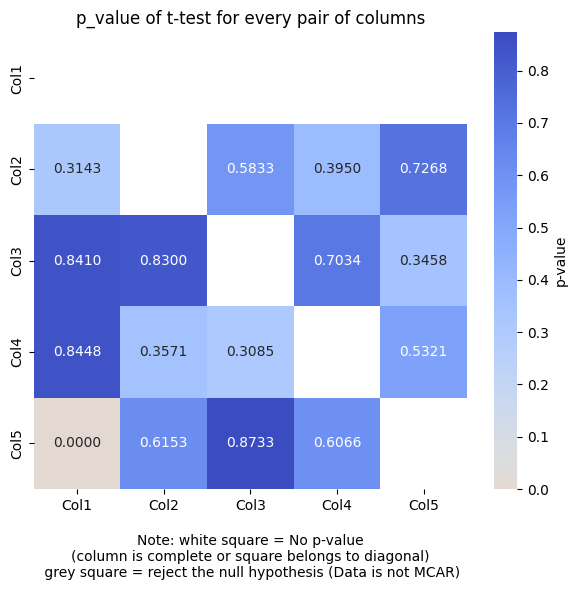

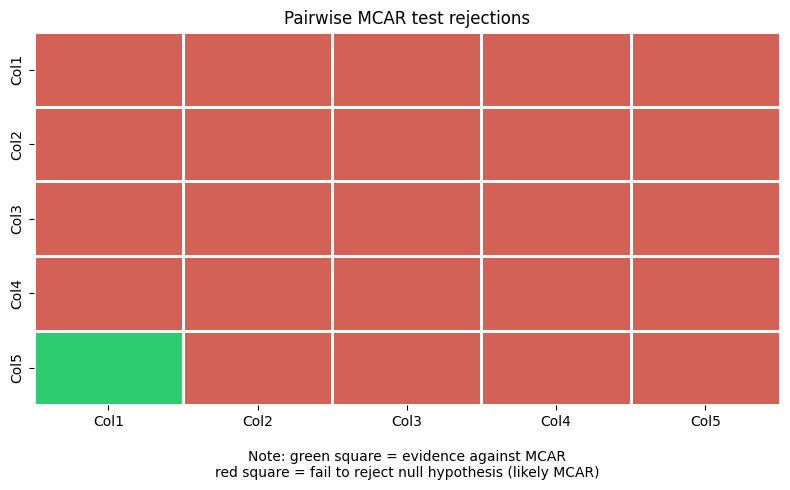

In [7]:
from mechanism_viewer import plot_mcar_pairwise

fig_p_values, ax_p_values, fig_reject, ax_reject = plot_mcar_pairwise(
    p_values,
    alpha=0.05,
    display_plot=True,
    )

From the displayed plots, it is visible that there is a relationship between Col5 and Col1. Indeed, the missing values of Col5 depend on the values of Col1, which makes the returned p-value for this pair close to 0. The green square in Col5-Col1 expresses that there is evidence against MCAR. In other words, it is likely that Col5 has MAR missing data mechanism that is related to Col1 (As stated before, the test cannot easily detect MNAR missing pattern).